**Machine Intelligence II**

**Independent Component Analysis: Infomax**

**Group members: Nikita Bauer, Anastasija Markovska, Ibrahim Ulas Ayyilmaz, Rezwana Hussainzada**

---

**Exercise H5.1: Initialization**

*(a)* Load the sound files. Each of the $N = 2$ sources is sampled at $8192 Hz$ and contains $p = 18000$ samples.


In [97]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [98]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
import re
import IPython.display as ipd

In [99]:
path1 = '/content/drive/MyDrive/MI2/Sheet05/sound1.dat'
path2 = '/content/drive/MyDrive/MI2/Sheet05/sound2.dat'

source1 = np.loadtxt(path1)
source2 = np.loadtxt(path2)

print("Source 1 shape:", source1.shape)
print("Source 2 shape:", source2.shape)

S = np.vstack([source1, source2])
print("\nShape of S:", S.shape)

Source 1 shape: (18000,)
Source 2 shape: (18000,)

Shape of S: (2, 18000)


*(b)* Create a random and invertible $N × N$ mixing matrix $A$ and mix the sources:
$$x^{(α)} = A s^{(α)} \ \ \ α = 1, . . . , p$$


In [100]:
A = np.random.randn(2, 2)

while np.abs(np.linalg.det(A)) < 1e-4:
    A = np.random.randn(2, 2)
print("Invertible Mixing Matrix A:")
print(A)
print("\nDeterminant of A:", np.linalg.det(A))

X = A @ S
print("\nShape of X:", X.shape)

Invertible Mixing Matrix A:
[[-0.23415337 -0.23413696]
 [ 1.57921282  0.76743473]]

Determinant of A: 0.19005465128700544

Shape of X: (2, 18000)


*(c)* Remove the temporal structure by permuting randomly the columns of the $N×p$ data matrix $X = (x^{(1)}, . . . , x^{(p)})$. Use these shuffled mixtures data in all subsequent steps.



In [101]:
p = X.shape[1]
shuffled_indices = np.random.permutation(p)
X_shuffled = X[:, shuffled_indices]
print("Shuffled Matrix Shape:", X_shuffled.shape)

Shuffled Matrix Shape: (2, 18000)


*(d)* Calculate the correlations between the sources and the mixtures: $ρ_{s_i,x_j} = \frac{cov(s_i, x_j)}{σ_{s_i}σ_{x_j}}$, with covariance in the numerator and standard deviations in the denominator.


In [102]:
N = 2
rho_matrix = np.zeros((N, N))


for i in range(N):
  for j in range(N):
    si = S[i, :]
    xj = X_shuffled[j, :]

    covariance_matrix = np.cov(si, xj)[0, 1]

    sigma_si = np.std(si, ddof=1)
    sigma_xj = np.std(xj, ddof=1)

    rho_matrix[i, j] = covariance_matrix / (sigma_si * sigma_xj)

print("Correlation Matrix:")
for i in range(N):
    for j in range(N):
        print(f"Correlation between Source {i+1} and Mixture {j+1}: {rho_matrix[i, j]:.2f}")

Correlation Matrix:
Correlation between Source 1 and Mixture 1: -0.00
Correlation between Source 1 and Mixture 2: 0.00
Correlation between Source 2 and Mixture 1: 0.01
Correlation between Source 2 and Mixture 2: -0.01


Pearson's correlation coefficient measures the strength and direction of the linear relationship between two continuous variables.
$$\rho_{s_i, x_j} = \frac{\text{cov}(s_i, x_j)}{\sigma_{s_i} \sigma_{x_j}}$$
The sign indicates how variables move together. Positive (+) means both increase/decrease together; negative (-) means as one increases, the other decreases. The closer the absolute value is to 1, the stronger the linear relationship. We can see here correlations between sources and mixed and shuffled data are close to zero. In a standard mixing scenario ($X = AS$), the mixtures $X$ normally exhibit a strong linear correlation with the original sources $S$. However, because we randomly permuted (shuffled) the columns of the data matrix $X$, any alignment and structured linear correlation between the time-points of the original sources and the observed mixtures have been completely destroyed.


*(e)* Center the data s.t. that each observed variable $x_i$ has zero mean.

In [103]:
X_centered = X_shuffled - np.mean(X_shuffled, axis=1, keepdims=True)
print("Centered Matrix Shape:", X_centered.shape)

Centered Matrix Shape: (2, 18000)


*(f)* Initialize the unmixing matrix $W$ with random values.


In [104]:
np.random.seed(42)
W_init = np.random.randn(2, 2)

print("Initialized Unmixing Matrix W:\n", W_init)

Initialized Unmixing Matrix W:
 [[ 0.49671415 -0.1382643 ]
 [ 0.64768854  1.52302986]]


---

**Exercise H5.2: Optimization**

Implement a matrix version of the ICA online learning algorithm that iterates as often as required over the training data. For $\hat{f}(·)$ use the logistic function (see lecture slides). This should reduce your code for this part to a few lines. Implement two variants of this learning algorithm:

*(a)* Compute the update matrix $ΔW$ using the standard gradient.

*(b)* Compute the update matrix $ΔW$ using the natural gradient as described in the lecture.

*(c)* Find a suitable learning rate ε that decays exponentially (but sufficiently slowly: e.g. $ε_0 =0.01$, $ε_{t+1} = 0.9999 ε_t$), and apply both gradient algorithms to the data (after it has been shuffled and centered) for unmixing the sources.





In [105]:
def f (y): return 1 / (1 + np.exp(-y))
def z(y): return 1 - 2*f(y)

N = X_centered.shape[0]
p = X_centered.shape[1]

# =====================================================================
# (a) Standard Gradient
# =====================================================================

def standard_gradient(W_init, X_centered, rate):
  W_standard = W_init.copy()
  F_norm_standard = []

  for t in range(p):
    xt = X_centered[:, t]
    yt = W_standard @ xt
    zt = z(yt)
    dW = np.linalg.inv(W_standard.T) + np.outer(zt, xt)
    if (t+1) % 1000 == 0:
      f_norm = np.sum(dW ** 2)
      F_norm_standard.append(f_norm)

    W_standard += rate * dW
    rate = rate * 0.9999

  return W_standard, F_norm_standard


rate = 0.01

W_standard, F_norm_standard = standard_gradient(W_init, X_centered, rate)

print("Standard Gradient Unmixing Matrix W:\n", W_standard)

# =====================================================================
# (b) Natural Gradient
# =====================================================================

def natural_gradient(W_init, X_centered, rate):
  W_natural = W_init.copy()
  F_norm_natural = []

  for t in range(p):
    xt = X_centered[:, t]
    yt = W_natural @ xt
    zt = z(yt)
    dW = (np.eye(N) + np.outer(zt, yt)) @ W_natural
    if (t+1) % 1000 == 0:
      f_norm = np.sum(dW ** 2)
      F_norm_natural.append(f_norm)

    W_natural += rate * dW
    rate = rate * 0.9999

  return W_natural, F_norm_natural

rate = 0.01
W_natural, F_norm_natural = natural_gradient(W_init, X_centered, rate)

print("Natural Gradient Unmixing Matrix W:\n", W_natural)


Standard Gradient Unmixing Matrix W:
 [[9.98058227 1.44137104]
 [4.63829826 1.91557607]]
Natural Gradient Unmixing Matrix W:
 [[14.34557153  2.0797743 ]
 [ 9.00598918  2.74249541]]


The core goal of the Infomax algorithm is maximizing the mutual information between inputs (mixed signals) and outputs (recovered sources) of a system yields independent outputs. We solve this optimization problem using online gradient ascent. In online learning, we compute the gradient of the Emprical Risk Minimization with respect to the weights for each incoming sample:

**Standard Gradient Method:**
The partial derivative for each weight is given by:
$$\frac{\partial e}{\partial w_{ij}} = W^{-1}_{ji} + \frac{\hat{f}''(\Sigma_{k=1}^{N}w_{ik}x_k^{(\alpha)})}{\hat{f}'(\Sigma_{k=1}^{N}w_{ik}x_k^{(\alpha)})}\cdot x_j^{(\alpha)}$$

which we can write:

$$\frac{\partial e}{\partial w_{ij}} = W^{-1}_{ji} + z_i x_j$$

where $z_i = \frac{\hat{f}''(y_i)}{\hat{f}'(y_i)}$ and $y_i = \sum_{k} w_{ik}x_k$.

In the vectorized matrix version, the first term turns into the transpose inverse of the weight matrix:

$$\Delta W = \epsilon \left( W^{-T} + z x^T \right)$$

**2. Natural Gradient Method:**

The natural gradient is achieved by multiplying the standard gradient by $W^T W$, which scales and normalizes the step size:

$$\Delta W = \epsilon \frac{\partial e}{\partial W} W^T W$$

the natural gradient for infomax becomes:

$$\Delta w_{ij} = \epsilon \Sigma_{l=1}^{N}\{ δ_{il} + \frac{\hat{f}''(\Sigma_{k=1}^{N}w_{ik}x_k^{(\alpha)})}{\hat{f}'(\Sigma_{k=1}^{N}w_{ik}x_k^{(\alpha)})} Σ_{k=1}^N w_{lk}x_k^{(\alpha)}\} w_{lj}$$

In the vectorized matrix version, we have

$$\Delta W = \epsilon \left( I + z y^T \right) W$$
*(where $y = Wx$)*

By utilizing the natural gradient, the term $W^{-T}$ is eliminated. This means *no computationally expensive matrix inversion for $W$ is necessary* during the online updates, leading to a much faster and numerically stable implementation.

---

**Exercise H5.3: Results**

*(a)* Plot & Play

*   (i)  the original sounds,
*   (ii) the mixed sources (before and after the data permutation),
*   (iii) the reconstructed signals (estimated sources) $\hat{s} =Wx$ using the unpermuted data.

--- (i) Original Sounds ---


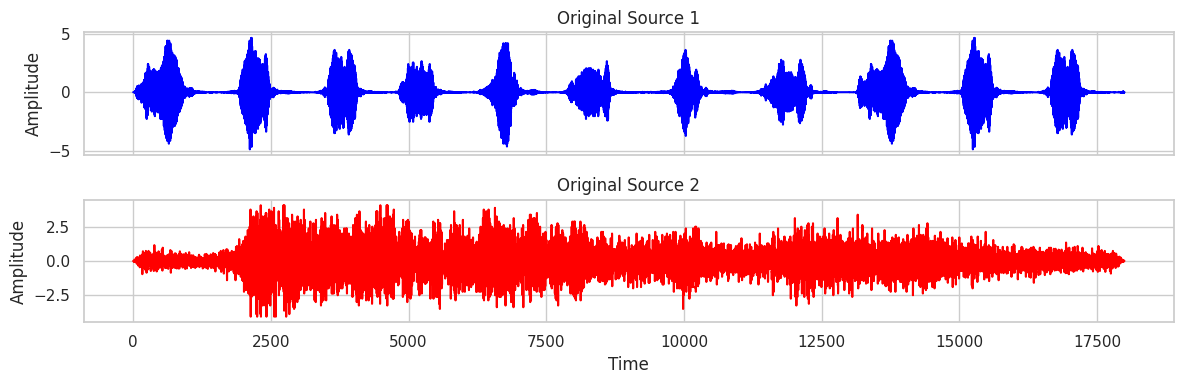

Play Source 1:


Play Source 2:


In [106]:
fs = 8192

# =====================================================================
# (i) Original Sounds
# =====================================================================
print("--- (i) Original Sounds ---")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
ax1.plot(source1, label="Original Source 1", color="blue")
ax1.set_title("Original Source 1")
ax1.set_ylabel("Amplitude")
ax1.grid(True)

ax2.plot(source2, label="Original Source 2", color="red")
ax2.set_title("Original Source 2")
ax2.set_xlabel("Time")
ax2.set_ylabel("Amplitude")
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Play Source 1:")
ipd.display(ipd.Audio(source1, rate=fs))
print("Play Source 2:")
ipd.display(ipd.Audio(source2, rate=fs))



--- (ii) Mixed Sources (Before and After Permutation) ---


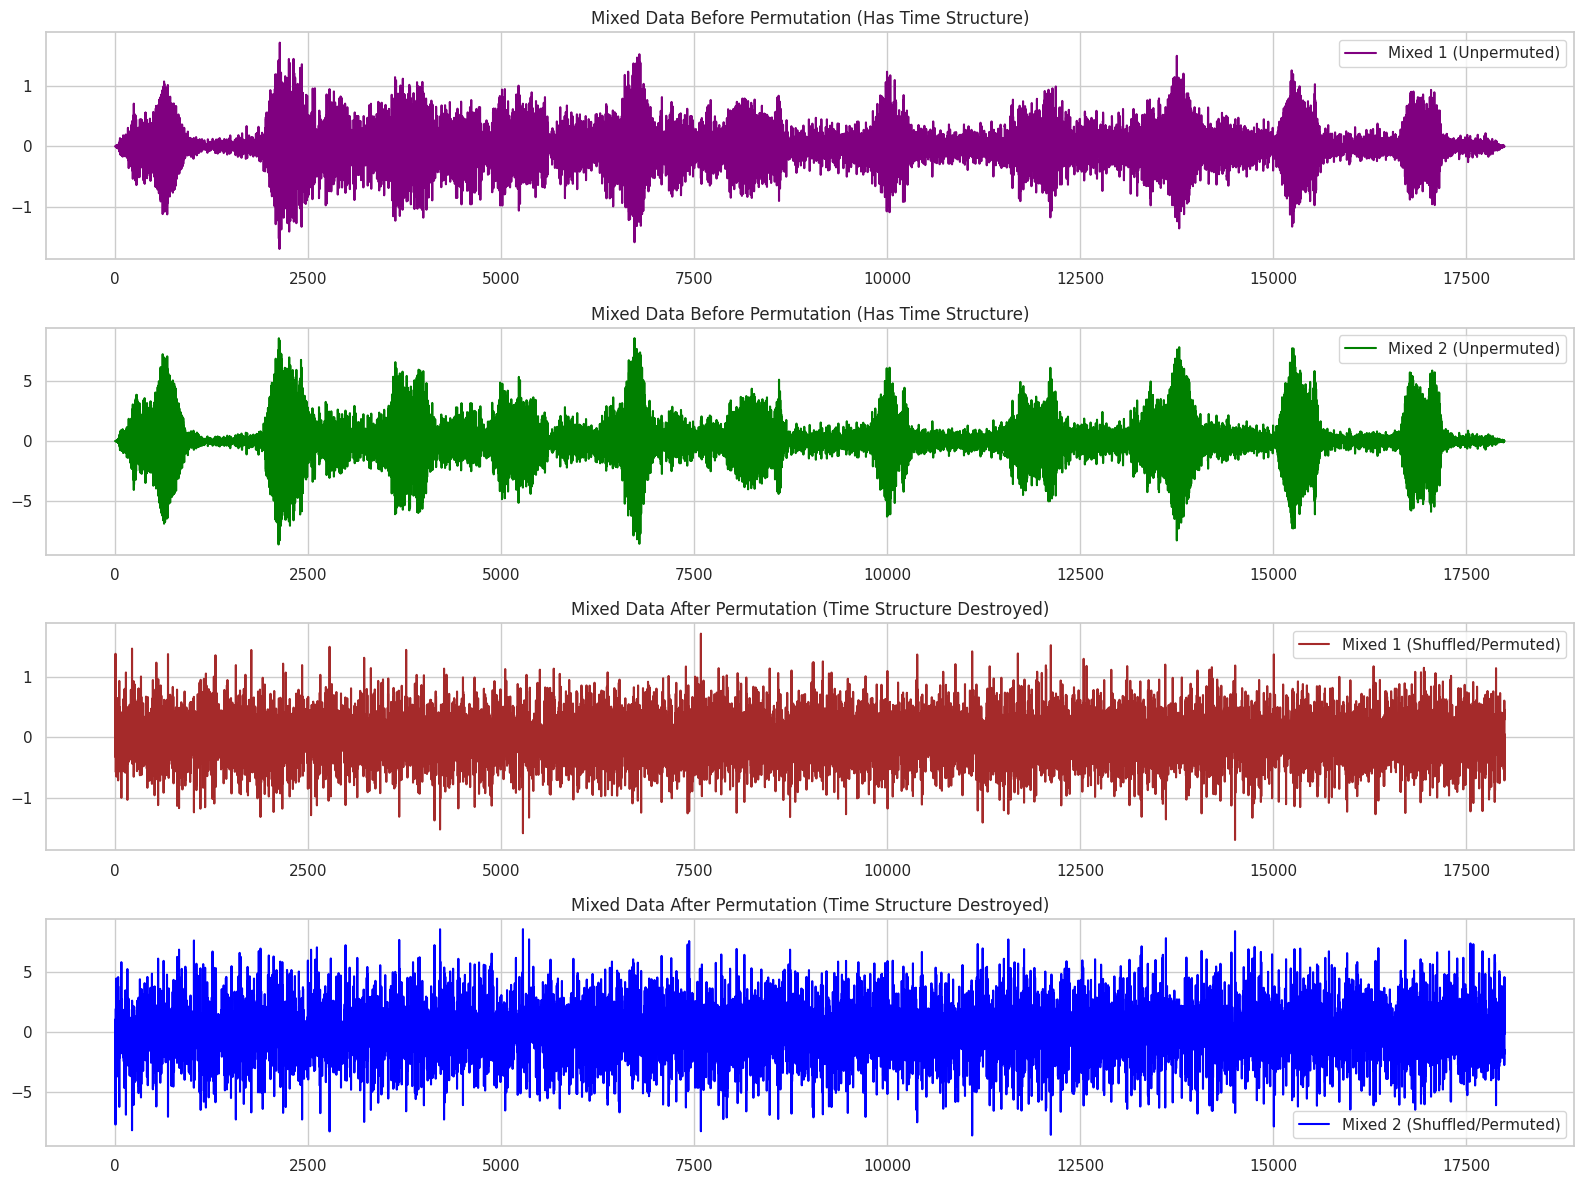

Play Mixed 1 (Before Permutation):


Play Mixed 2 (Before Permutation):


Play Mixed 1 (After Permutation - Shuffled):


Play Mixed 2 (After Permutation - Shuffled):


In [107]:
# =====================================================================
# (ii) Mixed Sources
# =====================================================================
print("\n--- (ii) Mixed Sources (Before and After Permutation) ---")

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 12))
ax1.plot(X[0], label="Mixed 1 (Unpermuted)", color="purple")
ax1.set_title("Mixed Data Before Permutation (Has Time Structure)")
ax1.grid(True)
ax1.legend()

ax2.plot(X[1], label="Mixed 2 (Unpermuted)", color="green")
ax2.set_title("Mixed Data Before Permutation (Has Time Structure)")
ax2.grid(True)
ax2.legend()


ax3.plot(X_shuffled[0], label="Mixed 1 (Shuffled/Permuted)", color="brown")
ax3.set_title("Mixed Data After Permutation (Time Structure Destroyed)")
ax3.grid(True)
ax3.legend()

ax4.plot(X_shuffled[1], label="Mixed 2 (Shuffled/Permuted)", color="blue")
ax4.set_title("Mixed Data After Permutation (Time Structure Destroyed)")
ax4.grid(True)
ax4.legend()

plt.tight_layout()
plt.show()

print("Play Mixed 1 (Before Permutation):")
ipd.display(ipd.Audio(X[0], rate=fs))
print("Play Mixed 2 (Before Permutation):")
ipd.display(ipd.Audio(X[1], rate=fs))
print("Play Mixed 1 (After Permutation - Shuffled):")
ipd.display(ipd.Audio(X_shuffled[0], rate=fs))
print("Play Mixed 2 (After Permutation - Shuffled):")
ipd.display(ipd.Audio(X_shuffled[1], rate=fs))





--- (iii) reconstructed Signals (Estimated Sources) ---


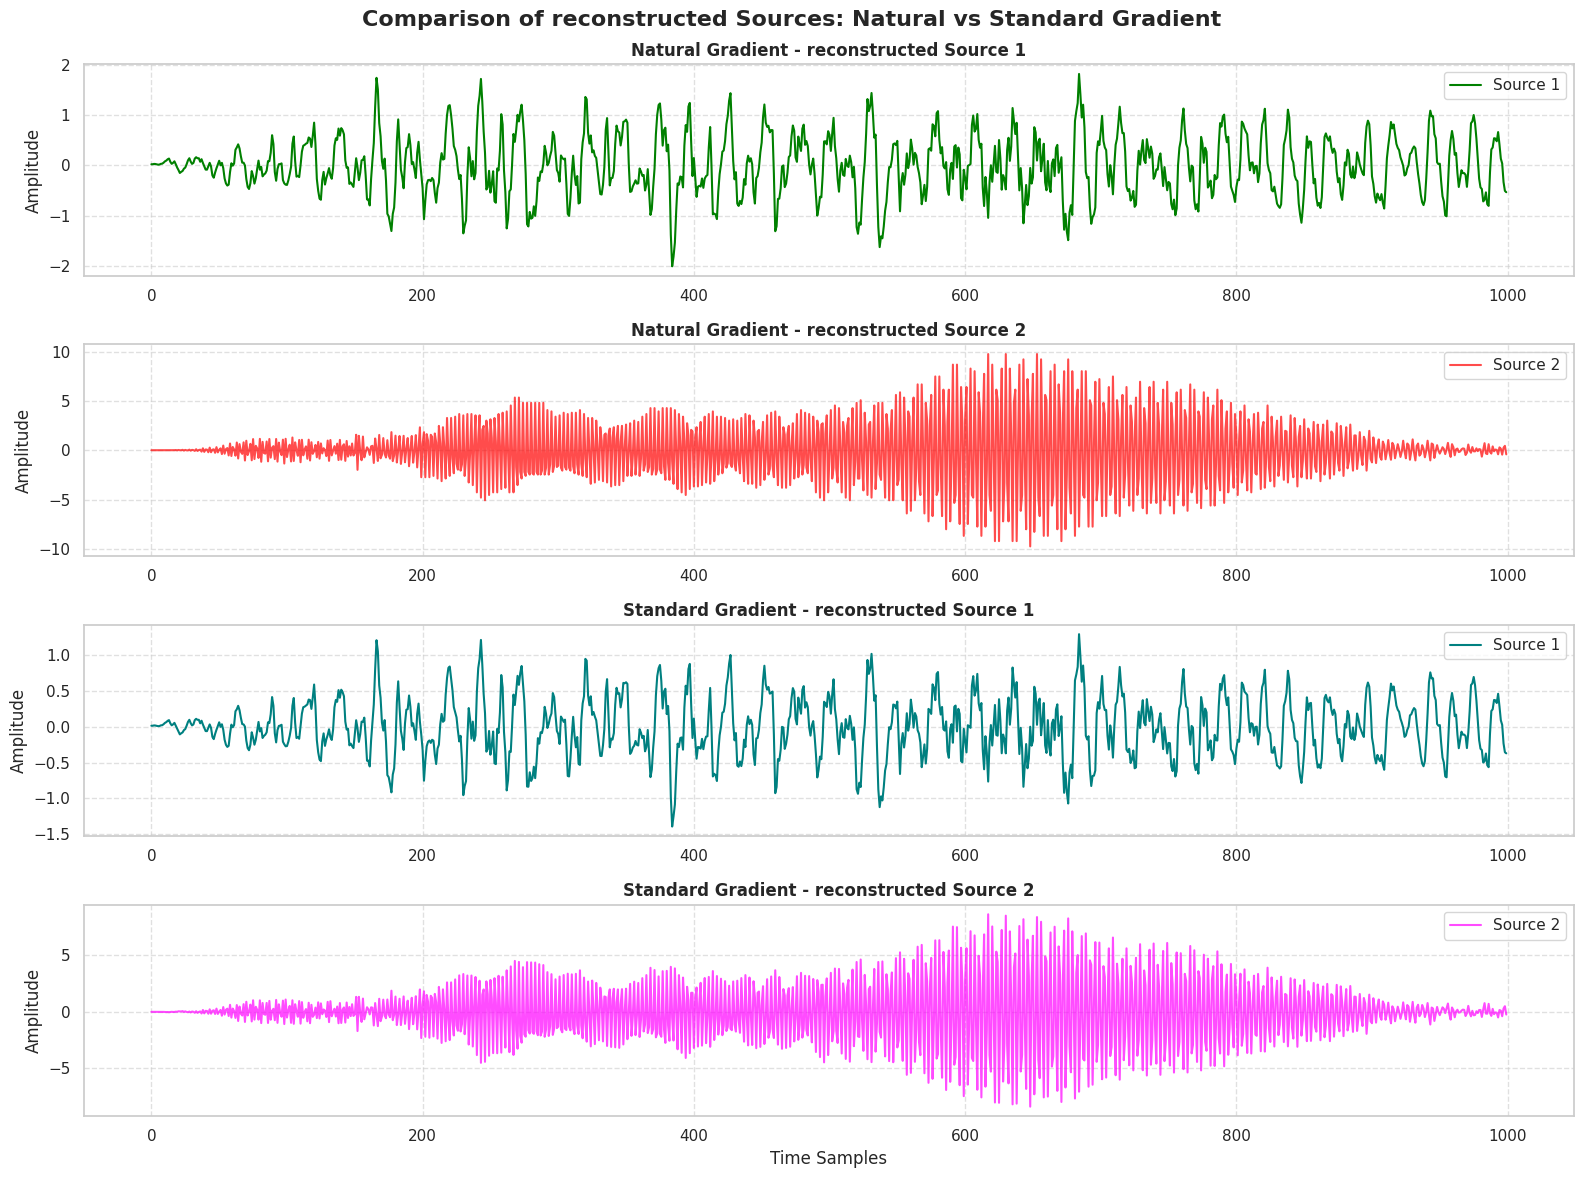

==> Play reconstructed Sounds from Natural Gradient:
reconstructed Source 1:


reconstructed Source 2:


==> Play reconstructed Sounds from Standard Gradient:
reconstructed Source 1:


reconstructed Source 2:


In [108]:
# =====================================================================
# (iii) reconstructed Signals
# =====================================================================
print("\n--- (iii) reconstructed Signals (Estimated Sources) ---")

X_c = X - np.mean(X, axis=1, keepdims=True)
S_natural = W_natural @ X_c
S_standard = W_standard @ X_c


fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(16, 12))

ax1.plot(S_natural[0][:1000], color='green', label="Source 1")
ax1.set_title("Natural Gradient - reconstructed Source 1", fontsize=12, fontweight='bold')
ax1.set_ylabel("Amplitude")
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc="upper right")

ax2.plot(S_natural[1][:1000], color='red', alpha=0.7, label="Source 2")
ax2.set_title("Natural Gradient - reconstructed Source 2", fontsize=12, fontweight='bold')
ax2.set_ylabel("Amplitude")
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc="upper right")

ax3.plot(S_standard[0][:1000], color='teal', label="Source 1")
ax3.set_title("Standard Gradient - reconstructed Source 1", fontsize=12, fontweight='bold')
ax3.set_ylabel("Amplitude")
ax3.grid(True, linestyle='--', alpha=0.6)
ax3.legend(loc="upper right")

ax4.plot(S_standard[1][:1000], color='magenta', alpha=0.7, label="Source 2")
ax4.set_title("Standard Gradient - reconstructed Source 2", fontsize=12, fontweight='bold')
ax4.set_xlabel("Time Samples")
ax4.set_ylabel("Amplitude")
ax4.grid(True, linestyle='--', alpha=0.6)
ax4.legend(loc="upper right")

fig.suptitle("Comparison of reconstructed Sources: Natural vs Standard Gradient", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


print("==> Play reconstructed Sounds from Natural Gradient:")
print("reconstructed Source 1:")
ipd.display(ipd.Audio(S_natural[0], rate=fs))
print("reconstructed Source 2:")
ipd.display(ipd.Audio(S_natural[1], rate=fs))

print("==> Play reconstructed Sounds from Standard Gradient:")
print("reconstructed Source 1:")
ipd.display(ipd.Audio(S_standard[0], rate=fs))
print("reconstructed Source 2:")
ipd.display(ipd.Audio(S_standard[1], rate=fs))


In [109]:
from scipy.io.wavfile import write
f = 8192
def save_audio(signal, filename):
    signal = signal / np.max(np.abs(signal)) # normalizing to avoid distortions when playing the sound
    write(filename, f, signal.astype(np.float32))

save_audio(source1, "original_source1.wav")
save_audio(source2, "original_source2.wav")
save_audio(X[0], "mixed_signal1.wav")
save_audio(X[1], "mixed_signal2.wav")
save_audio(X_shuffled[0], "mixed_shuffled_signal1.wav")
save_audio(X_shuffled[1], "mixed_shuffled_signal2.wav")
save_audio(S_natural[0], "reconstructed_natural_source1.wav")
save_audio(S_natural[1], "reconstructed_natural_source2.wav")
save_audio(S_standard[0], "reconstructed_standard_source1.wav")
save_audio(S_standard[1], "reconstructed_standard_source2.wav")


print("\nAll plots displayed, audio elements initialized, and WAV files successfully saved to workspace!")


All plots displayed, audio elements initialized, and WAV files successfully saved to workspace!


In [121]:
from google.colab import files

files.download("original_source1.wav")
files.download("original_source2.wav")
files.download("mixed_signal1.wav")
files.download("mixed_signal2.wav")
files.download("mixed_shuffled_signal1.wav")
files.download("mixed_shuffled_signal2.wav")
files.download("reconstructed_natural_source1.wav")
files.download("reconstructed_natural_source2.wav")
files.download("reconstructed_standard_source1.wav")
files.download("reconstructed_standard_source2.wav")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

*(b)* Calculate the correlations (as above) between the true sources and the estimations.


In [110]:
def Pearson_Correlation_Coefficient(S, estimated_source):
    N = 2
    rho_matrix = np.zeros((N, N))

    for i in range(N):
        for j in range(N):
            si = S[i, :]
            estimated_sj = estimated_source[j, :]

            covariance_matrix = np.cov(si, estimated_sj)[0, 1]

            sigma_si = np.std(si, ddof=1)
            sigma_estimated_sj = np.std(estimated_sj, ddof=1)

            rho_matrix[i, j] = covariance_matrix / (sigma_si * sigma_estimated_sj)

    print("Correlation Matrix between True Sources and Estimations:")
    for i in range(N):
        for j in range(N):
            print(f"Correlation between True Source {i+1} and Estimated Source {j+1}: {rho_matrix[i, j]:.4f}")

    return rho_matrix


print("===== Natural Gradient Results =====")
rho_natural = Pearson_Correlation_Coefficient(S, S_natural)

print("\n===== Standard Gradient Results =====")
rho_standard = Pearson_Correlation_Coefficient(S, S_standard)

===== Natural Gradient Results =====
Correlation Matrix between True Sources and Estimations:
Correlation between True Source 1 and Estimated Source 1: -0.0436
Correlation between True Source 1 and Estimated Source 2: 1.0000
Correlation between True Source 2 and Estimated Source 1: -0.9991
Correlation between True Source 2 and Estimated Source 2: -0.0005

===== Standard Gradient Results =====
Correlation Matrix between True Sources and Estimations:
Correlation between True Source 1 and Estimated Source 1: -0.0505
Correlation between True Source 1 and Estimated Source 2: 0.9809
Correlation between True Source 2 and Estimated Source 1: -0.9988
Correlation between True Source 2 and Estimated Source 2: 0.1956


we calculated the Pearson correlation coefficients between the *True Sources* and the *Estimated Sources* ($\hat{s} = Wx$) for both gradient variants.

*Natural Gradient* achieves an almost perfect separation with a correlation of $1.0000$ for the first source and $-0.9991$ for the second source.

*Standard Gradient* also performs very well but shows slightly lower precision.


*(c)* For every $1000^{th}$ update, plot the square of the Frobenius norm $||ΔW||^2_F :=\Sigma_{i=1,j=1}^{N}(Δw_{ij})^2$ to compare the convergence speed for the two gradient methods. Whiten your data before applying ICA and compare the learning speeds again. Describe the differences between the two variants of the learning algorithm.



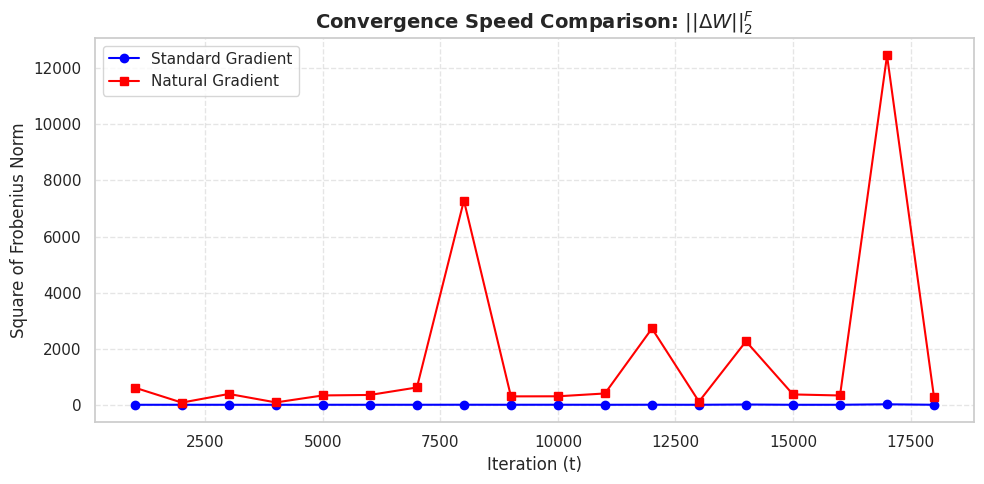

In [111]:
# =====================================================================
# Frobenius norm
# =====================================================================

# Plot

iterations = np.arange(1000, p + 1, 1000)

plt.figure(figsize=(10, 5))
plt.plot(iterations, F_norm_standard, label='Standard Gradient', color='blue', marker='o', linestyle='-')
plt.plot(iterations, F_norm_natural, label='Natural Gradient', color='red', marker='s', linestyle='-')

plt.title("Convergence Speed Comparison: $||\\Delta W||_2^F$", fontsize=14, fontweight='bold')
plt.xlabel("Iteration (t)", fontsize=12)
plt.ylabel("Square of Frobenius Norm", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


In [112]:
# =====================================================================
#  Whitening data
# =====================================================================
X = X_centered.copy()
p = X.shape[1]
C = np.cov(X)
eigenvalues_C, M = np.linalg.eigh(C)

idx_C = eigenvalues_C.argsort()[::-1]
eigenvalues_C = eigenvalues_C[idx_C]
M = M[:, idx_C]

Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(eigenvalues_C + 1e-5))

V = Lambda_inv_sqrt @ M.T @ X

X_whitened = V

print("Whitened Data Shape:", X_whitened.shape)

print("Covariance Matrix of V (Should be Identity matrix):")
print(np.round(np.cov(X_whitened), 4))


print("Covariance Matrix of centered X (Should be Identity matrix):")
print(np.round(np.cov(X_centered), 4))

Whitened Data Shape: (2, 18000)
Covariance Matrix of V (Should be Identity matrix):
[[ 1.     -0.    ]
 [-0.      0.9991]]
Covariance Matrix of centered X (Should be Identity matrix):
[[ 0.1095 -0.5487]
 [-0.5487  3.0775]]


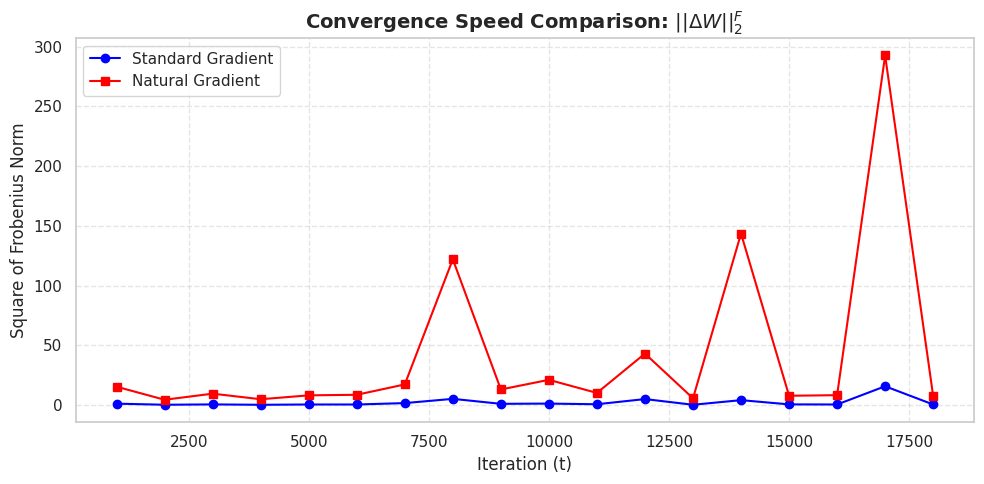

In [113]:
def f (y): return 1 / (1 + np.exp(-y))

def z(y): return 1 - 2*f(y)

N = X_centered.shape[0]
p = X_centered.shape[1]

W = W_init.copy()

# Standard Gradient
rate = 0.01

W_standard_whiten, F_norm_standard_whiten = standard_gradient(W, X_whitened, rate)
# Natural Gradient
rate = 0.01

W_natural_whiten, F_norm_natural_whiten = natural_gradient(W, X_whitened, rate)

# Plot

iterations = np.arange(1000, p + 1, 1000)

plt.figure(figsize=(10, 5))
plt.plot(iterations, F_norm_standard_whiten, label='Standard Gradient', color='blue', marker='o', linestyle='-')
plt.plot(iterations, F_norm_natural_whiten, label='Natural Gradient', color='red', marker='s', linestyle='-')

plt.title("Convergence Speed Comparison: $||\\Delta W||_2^F$", fontsize=14, fontweight='bold')
plt.xlabel("Iteration (t)", fontsize=12)
plt.ylabel("Square of Frobenius Norm", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


Based on our specific plots of the squared Frobenius norm $||\Delta W||_2^F$, we observe the following behavior:

On Unwhitened Data: Appears as a very smooth, and slowly decaying curve. Red Shows a sharp initial drop followed by fluctuations.

Natural Gradient Stabilization, the absolute magnitude of its initial weight updates ($||\Delta W||_2^F$) drops significantly compared to the unwhitened phase.


M is a matrix containing in its columns the normalized eigenvectors of the covariance matrix C of the centered data $X \in \mathbb{R}^{N \times p}$ and $\Lambda$ is a diagonal matrix containing the corresponding eigenvalues.

The whitening transformation matrix $V$ is then computed by:
$$V = \Lambda^{-\frac{1}{2}} M^T X$$

*(d)* Plot the density of the mixed, unmixed, and true signals & interpret your results.

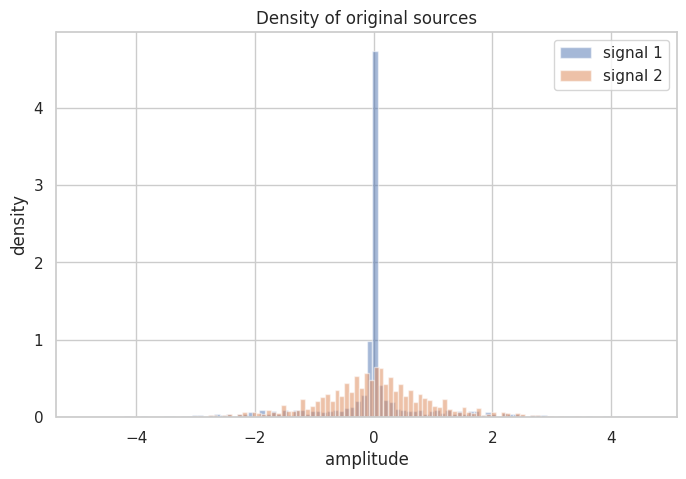

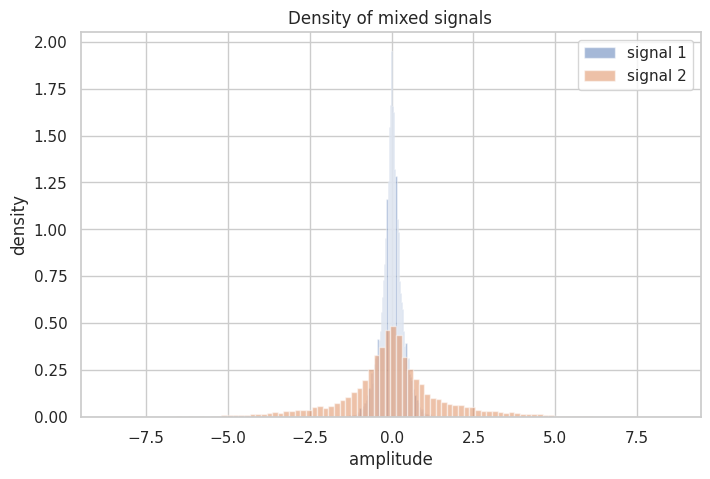

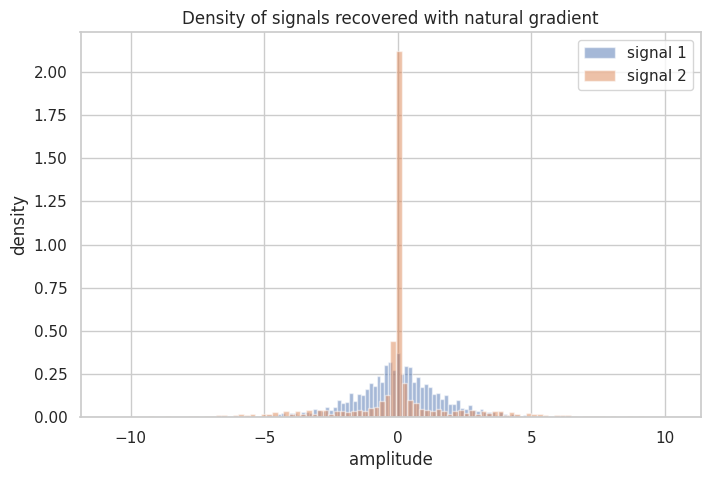

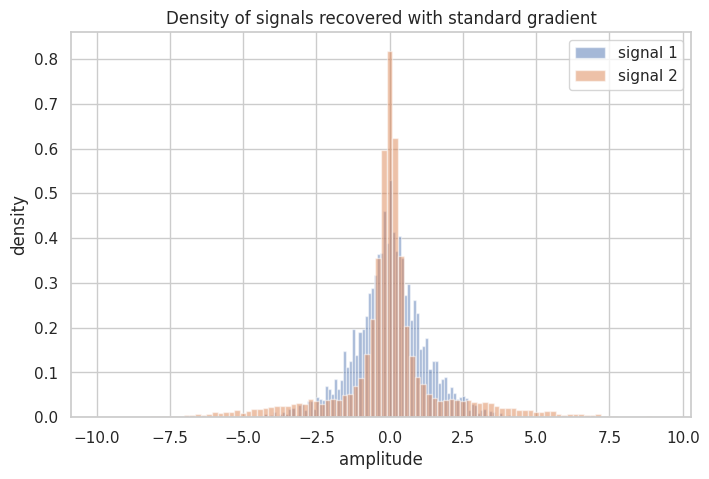

In [115]:
def plot_density(data, title, bins=100):
    plt.figure(figsize=(8,5))
    plt.hist(data[0], bins=bins, density=True, alpha=0.5, label="signal 1")
    plt.hist(data[1], bins=bins, density=True, alpha=0.5, label="signal 2")
    plt.title(title)
    plt.xlabel("amplitude")
    plt.ylabel("density")
    plt.legend()

plot_density(S, "Density of original sources")
plot_density(X, "Density of mixed signals")
plot_density(S_natural, "Density of signals recovered with natural gradient")
plot_density(S_standard, "Density of signals recovered with standard gradient")


The original sound sources exhibit highly *Non-Gaussian* distributions. They are characterized by sharp, high peaks around zero and heavy tails.

Once the sources are mixed ($X = AS$), the resulting distribution transforms into a smooth, bell-shaped curve that resembles a Gaussian (Normal) distribution.

The estimated sources ($\hat{s}$) successfully recover the exact non-Gaussian shape, and peaks of the original *True Signals*. This is also shown by the correlations.

While the standard gradient also breaks the Gaussian mix and shifts the data back toward a non-Gaussian form, its distributions are slightly wider and less precise compared to the true sources.